# Adaptive quantum metrology under a fixed measurement budget — a code walkthrough

This notebook is a self-contained, readable companion to the thesis *“Evaluating adaptive quantum
metrology protocols for parameter search under resource constraints.”* It explains, with small live
examples, **what the simulation does and how the algorithms work**, then shows the headline results.

All code is imported from the [`qmetrology`](qmetrology/) package — nothing is re-implemented here.
If you only want to regenerate the paper's tables, use [`reproduce.ipynb`](reproduce.ipynb) instead.

**The problem in one sentence.** An unknown phase $\phi$ is encoded in a quantum circuit; using a
limited number of measurements (a *budget*), estimate $\phi$ as accurately as possible.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from qmetrology.sim import simulate_errors
from qmetrology import algorithms as alg
from qmetrology.experiments import success_rate
rng = np.random.default_rng(0)
plt.rcParams['figure.figsize'] = (7, 3.2)

## 1. The model

We use the maximally-entangled (GHZ) protocol with $N$ phase gates. Measuring the circuit returns
outcome “0” with probability
$$p_0 = \cos^2(N\phi).$$
We repeat the measurement $m$ times (*shots*), estimate $\hat p_0 = \text{hits}/m$, and invert:
$$\hat\phi = \tfrac{1}{N}\arccos\!\big(\sqrt{\hat p_0}\,\big).$$

The **cost** (budget) of one run is $C = N\cdot m$. A run **converges** if $|\hat\phi-\phi| < \epsilon$.
The whole point of the thesis is how to spend a fixed budget between $N$ (circuit depth) and $m$
(repetitions). Here is a single estimate:

In [2]:
phi_true = 0.05
phi_hat = simulate_errors(rng, phi_true, m=500, N=15)
print(f'true phi = {phi_true},  estimate = {phi_hat:.5f},  |error| = {abs(phi_hat-phi_true):.5f}')

true phi = 0.05,  estimate = 0.05209,  |error| = 0.00209


### 1.1  More shots → sharper estimate

For fixed $N$, the estimator's variance scales like $1/(4N^2 m)$ (the quantum Cramér–Rao bound). So
increasing $m$ concentrates $\hat\phi$ around the true value:

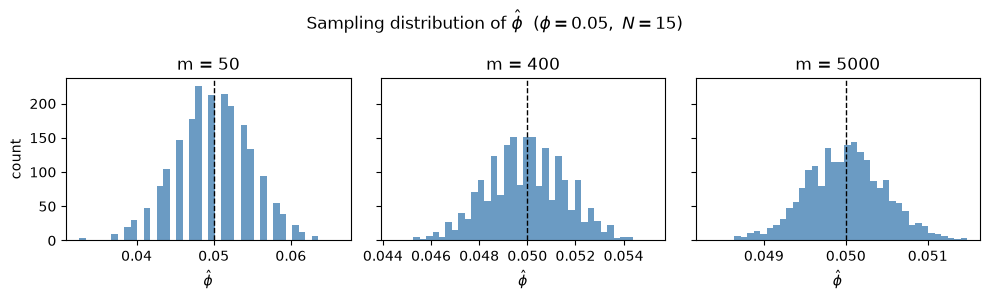

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(10, 3), sharey=True)
for ax, m in zip(axes, [50, 400, 5000]):
    ests = np.array([simulate_errors(rng, 0.05, m, 15) for _ in range(2000)])
    ax.hist(ests, bins=40, color='steelblue', alpha=.8)
    ax.axvline(0.05, color='k', ls='--', lw=1)
    ax.set_title(f'm = {m}'); ax.set_xlabel(r'$\hat\phi$')
axes[0].set_ylabel('count'); fig.suptitle(r'Sampling distribution of $\hat\phi$  ($\phi=0.05,\ N=15$)')
plt.tight_layout(); plt.show()

### 1.2  Why choosing $N$ is hard: the overshoot trap

Larger $N$ also sharpens the estimate (Heisenberg scaling $\propto 1/N^2$), so we *want* $N$ large.
**But** the inversion $\arccos$ is only valid while $N\phi < \pi/2$. Past the optimal
$N_{\text{opt}} = \lfloor \pi/(2\phi)\rfloor$, the estimate collapses toward $0$. Since $\phi$ is
*unknown*, we don't know $N_{\text{opt}}$ in advance — which is exactly what the adaptive algorithms
must discover. The collapse is clearly visible:

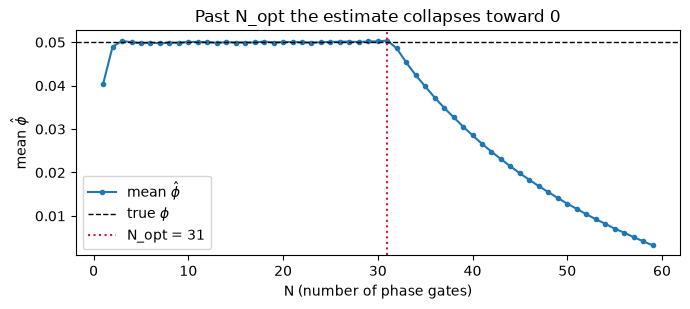

In [4]:
phi0 = 0.05; N_opt = int(np.pi // (2*phi0))
Ns = np.arange(1, 60)
means = [np.mean([simulate_errors(rng, phi0, 500, int(N)) for _ in range(300)]) for N in Ns]
plt.plot(Ns, means, marker='.', label=r'mean $\hat\phi$')
plt.axhline(phi0, color='k', ls='--', lw=1, label=r'true $\phi$')
plt.axvline(N_opt, color='crimson', ls=':', label=f'N_opt = {N_opt}')
plt.xlabel('N (number of phase gates)'); plt.ylabel(r'mean $\hat\phi$')
plt.title('Past N_opt the estimate collapses toward 0'); plt.legend(); plt.tight_layout(); plt.show()

## 2. The algorithms

All take a budget and the known *range* $\phi\in[\phi_{\min},\phi_{\max}]$, and return
$(\hat\phi,\ \text{budget used})$.

| Algorithm | Idea |
|---|---|
| **Brute force** | Play safe: fix $N=N_{\min}=\lfloor\pi/(2\phi_{\max})\rfloor$ (valid for the whole range), spend all budget on shots. |
| **Linear search** | Scan $N$ upward in small steps; when the running estimate trends *down* (overshoot), back off. |
| **Binary search** | Divide-and-conquer on $N$ using a confidence bound on $\hat\phi$. |
| **Reverse engineering** | Take one cheap estimate $\hat\phi_0$, infer $N\approx\pi/(2\hat\phi_0)$, then exploit. |

Running each once on an example $\phi$ (budget 10,000, range $[0.01,0.1]$):

In [5]:
phi_max, phi_min, phi = 0.1, 0.01, 0.037
runs = [
    ('brute force', alg.find_phi_fixed_budget_brute_force, dict(budget=10_000)),
    ('linear search', alg.find_phi_fixed_budget_linear_search, dict(m_exploration=10, budget=10_000)),
    ('binary search', alg.find_phi_fixed_budget_binary_search, dict(m_exploration=100, budget=10_000)),
    ('reverse eng.', alg.find_phi_fixed_budget_reverse_engineering, dict(m_exploration=200, budget=10_000)),
]
for name, fn, p in runs:
    ph, b = fn(rng, phi, phi_max, phi_min, **p)
    conv = 'converged' if abs(ph - phi) < 1e-3 else 'no'
    print(f'{name:15s} phi_hat={ph:.5f}  |err|={abs(ph-phi):.5f}  budget={b:6.0f}  {conv}')

brute force     phi_hat=0.03823  |err|=0.00123  budget=  9990  no
linear search   phi_hat=0.03653  |err|=0.00047  budget= 10230  converged
binary search   phi_hat=0.00000  |err|=0.03700  budget= 10100  no
reverse eng.    phi_hat=0.03554  |err|=0.00146  budget=  9984  no


## 3. How performance is measured

We draw $\phi\sim\mathcal{U}(\phi_{\min},\phi_{\max})$, run $R$ independent trials (each with its own
seed), and report the **convergence rate** = fraction with $|\hat\phi-\phi|<\epsilon$. Everything is
explicitly seeded, so results are reproducible. Example — brute force at budget 10,000:

In [6]:
rate = success_rate(alg.find_phi_fixed_budget_brute_force, dict(budget=10_000),
                    R=5000, phi_min=0.01, phi_max=0.1, eps=1e-3, seed=1)
print(f'brute-force convergence at budget=10,000:  {rate*100:.1f}%')

brute-force convergence at budget=10,000:  57.1%


## 4. Headline result — best achievable at budget = 10,000 (narrow range)

Below we evaluate each algorithm at its *best budget-respecting configuration* (tuned separately, then
measured here on a fresh seed at $R=20{,}000$) and compare to the published Table 3.1. The published
linear/binary numbers were much lower — they appear to be stale; see the caveats below.

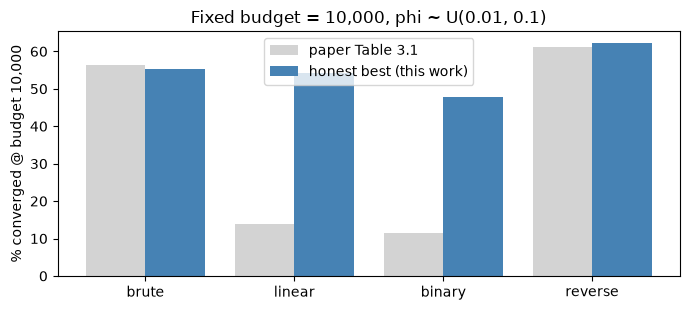

brute     paper= 56.3%   honest= 55.4%
linear    paper= 14.0%   honest= 54.2%
binary    paper= 11.5%   honest= 47.9%
reverse   paper= 61.3%   honest= 62.2%


In [7]:
best = {
    'brute':   (alg.find_phi_fixed_budget_brute_force, dict(budget=10_000)),
    'linear':  (alg.find_phi_fixed_budget_linear_search, dict(m_exploration=10, budget=10_000, lookback_window=2, safeguard=1, inc=1)),
    'binary':  (alg.find_phi_fixed_budget_binary_search, dict(m_exploration=10, budget=10_000, conf=0.5, safeguard=2)),
    'reverse': (alg.find_phi_fixed_budget_reverse_engineering, dict(m_exploration=33, budget=10_000, safeguard=0.8)),
}
paper = {'brute': 56.3, 'linear': 14.0, 'binary': 11.5, 'reverse': 61.3}
honest = {k: 100*success_rate(fn, p, 20000, 0.01, 0.1, 1e-3, 2024) for k,(fn,p) in best.items()}
labels = list(best); x = np.arange(len(labels))
plt.bar(x-0.2, [paper[k] for k in labels], 0.4, label='paper Table 3.1', color='lightgray')
plt.bar(x+0.2, [honest[k] for k in labels], 0.4, label='honest best (this work)', color='steelblue')
plt.xticks(x, labels); plt.ylabel('% converged @ budget 10,000'); plt.legend()
plt.title('Fixed budget = 10,000, phi ~ U(0.01, 0.1)'); plt.tight_layout(); plt.show()
for k in labels: print(f'{k:9s} paper={paper[k]:5.1f}%   honest={honest[k]:5.1f}%')

## 5. Caveats for the reader

Three measurement pitfalls were found while verifying the paper (full details in
[`results/verification_report.md`](results/verification_report.md) and
[`results/conv95_verdict.md`](results/conv95_verdict.md)):

1. **Winner's curse.** Reporting the *maximum* convergence over a large parameter grid (each measured at
   only $R=1000$) is upward-biased. Always tune on one seed and *report on an independent one*.
2. **Budget overspend.** The fixed-budget algorithms check the budget *after* each exploration step, so a
   large `m_exploration` can use ~2× the nominal cap. Track the *returned* budget, not the nominal one.
3. **The >95% budgets are optimistic.** The configs selected as “≥95% with least budget” actually
   converge only ~92–94% when re-checked; reaching a true 95% needs ~25–50% more budget.

None of these overturn the thesis's qualitative conclusions, but they shift the precise numbers.

## 6. Reproduce / explore further

- `python -m qmetrology.reproduce` — regenerate the fixed-budget tables + verification report.
- [`analysis/analysis_best_budget10k.py`](analysis/analysis_best_budget10k.py) — best achievable at budget 10,000.
- [`analysis/analysis_conv95.py`](analysis/analysis_conv95.py) — validate the >95%-convergence budgets.
- The algorithms live in [`qmetrology/algorithms.py`](qmetrology/algorithms.py); the simulator in
  [`qmetrology/sim.py`](qmetrology/sim.py).